In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

import glob
import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

from pangal.pangal import PanGal
from pangal.region import Region
from pangal.plot import Point, Contours
from pangal.run import Run
from pangal.pfitter import PFitter
from pangal.photometry_table import PhotometryTable, PhotometryCatalog

from regions import EllipseAnnulusPixelRegion, PixCoord, CirclePixelRegion
from astropy import units as u


repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, repo_root)
from multicornerplot import multi_corner_contours

import warnings
warnings.simplefilter("ignore")


# Load all results

In [2]:
ngc4848_1_allfree = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_pacs_upplim.npz')
ngc4848_2_allfree = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITSPEC_pacs_upplim.npz')
ngc4848_3_allfree = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITSPEC_pacs_upplim.npz')

ngc4848_1_noemm = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_pacs_upplim_FESC_1.npz')
ngc4848_2_noemm = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITSPEC_pacs_upplim_FESC_1.npz')
ngc4848_3_noemm = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITSPEC_pacs_upplim_FESC_1.npz')

ngc4848_1_noemm_BURST = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_noemission_pacs_upplim_BURST.npz')
ngc4848_1_BURST = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_pacs_upplim_BURST.npz')
ngc4848_2_BURST = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITSPEC_pacs_upplim_BURST.npz')
#ngc4848_3_BURST = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITSPEC_pacs_upplim_BURST.npz')

ngc4848_3_little_model = Run().load('DATA/Coma/NGC4848/dynesty_runs/REGION_3_little_model.npz')

Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_pacs_upplim.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITSPEC_pacs_upplim.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITSPEC_pacs_upplim.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_pacs_upplim_FESC_1.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITSPEC_pacs_upplim_FESC_1.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_3_FITSPEC_pacs_upplim_FESC_1.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_noemission_pacs_upplim_BURST.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_1_FITSPEC_pacs_upplim_BURST.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_2_FITSPEC_pacs_upplim_BURST.npz
Loaded fit results from DATA/Coma/NGC4848/dynesty_runs/REGION_3_little_model.npz


In [3]:
ic4040_1_allfree = Run().load('DATA/Coma/IC4040/dynesty_runs/REGION_1_SPECPHOT_noprior.npz')
ic4040_2_allfree = Run().load('DATA/Coma/IC4040/dynesty_runs/REGION_2_SPECPHOT_noprior.npz')
ic4040_3_allfree = Run().load('DATA/Coma/IC4040/dynesty_runs/REGION_3_SPECPHOT_noprior.npz')

ic4040_1_noemm = Run().load('DATA/Coma/IC4040/dynesty_runs/REGION_1_SPECPHOT_noemission_pacs_upplim.npz')
ic4040_2_noemm = Run().load('DATA/Coma/IC4040/dynesty_runs/REGION_2_SPECPHOT_noemission_pacs_upplim.npz')
ic4040_3_noemm = Run().load('DATA/Coma/IC4040/dynesty_runs/REGION_3_SPECPHOT_noemission_pacs_upplim.npz')

Loaded fit results from DATA/Coma/IC4040/dynesty_runs/REGION_1_SPECPHOT_noprior.npz
Loaded fit results from DATA/Coma/IC4040/dynesty_runs/REGION_2_SPECPHOT_noprior.npz
Loaded fit results from DATA/Coma/IC4040/dynesty_runs/REGION_3_SPECPHOT_noprior.npz
Loaded fit results from DATA/Coma/IC4040/dynesty_runs/REGION_1_SPECPHOT_noemission_pacs_upplim.npz
Loaded fit results from DATA/Coma/IC4040/dynesty_runs/REGION_2_SPECPHOT_noemission_pacs_upplim.npz
Loaded fit results from DATA/Coma/IC4040/dynesty_runs/REGION_3_SPECPHOT_noemission_pacs_upplim.npz


In [4]:
gmp3779_1_allfree = Run().load('DATA/Coma/GMP3779/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz')
gmp3779_2_allfree = Run().load('DATA/Coma/GMP3779/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz')
gmp3779_3_allfree = Run().load('DATA/Coma/GMP3779/dynesty_runs/REGION_3_SPECPHOT_pacs_upplim.npz')
gmp3779_4_allfree = Run().load('DATA/Coma/GMP3779/dynesty_runs/REGION_4_SPECPHOT_pacs_upplim.npz')

gmp3779_1_noemm = Run().load('DATA/Coma/GMP3779/dynesty_runs/REGION_1_SPECPHOT_noemission_pacs_upplim.npz')
gmp3779_2_noemm = Run().load('DATA/Coma/GMP3779/dynesty_runs/REGION_2_SPECPHOT_noemission_pacs_upplim.npz')
gmp3779_3_noemm = Run().load('DATA/Coma/GMP3779/dynesty_runs/REGION_3_SPECPHOT_noemission_pacs_upplim.npz')
gmp3779_4_noemm = Run().load('DATA/Coma/GMP3779/dynesty_runs/REGION_4_SPECPHOT_noemission_pacs_upplim.npz')


Loaded fit results from DATA/Coma/GMP3779/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP3779/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP3779/dynesty_runs/REGION_3_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP3779/dynesty_runs/REGION_4_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP3779/dynesty_runs/REGION_1_SPECPHOT_noemission_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP3779/dynesty_runs/REGION_2_SPECPHOT_noemission_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP3779/dynesty_runs/REGION_3_SPECPHOT_noemission_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP3779/dynesty_runs/REGION_4_SPECPHOT_noemission_pacs_upplim.npz


In [5]:
gmp3016_1_allfree = Run().load('DATA/Coma/GMP3016/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz')
gmp3016_2_allfree = Run().load('DATA/Coma/GMP3016/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz')
gmp3016_3_allfree = Run().load('DATA/Coma/GMP3016/dynesty_runs/REGION_3_SPECPHOT_pacs_upplim.npz')

Loaded fit results from DATA/Coma/GMP3016/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP3016/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP3016/dynesty_runs/REGION_3_SPECPHOT_pacs_upplim.npz


In [6]:
gmp4232_1_allfree = Run().load('DATA/Coma/GMP4232/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz')
gmp4232_2_allfree = Run().load('DATA/Coma/GMP4232/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz')
gmp4232_3_allfree = Run().load('DATA/Coma/GMP4232/dynesty_runs/REGION_3_SPECPHOT_pacs_upplim.npz')

Loaded fit results from DATA/Coma/GMP4232/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP4232/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/GMP4232/dynesty_runs/REGION_3_SPECPHOT_pacs_upplim.npz


In [7]:
d100_1_allfree = Run().load('DATA/Coma/D100/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz')
d100_2_allfree = Run().load('DATA/Coma/D100/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz')


Loaded fit results from DATA/Coma/D100/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/D100/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz


In [8]:
rb199_1_allfree = Run().load('DATA/Coma/RB199/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz')
rb199_2_allfree = Run().load('DATA/Coma/RB199/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz')
rb199_3_allfree = Run().load('DATA/Coma/RB199/dynesty_runs/REGION_3_SPECPHOT_pacs_upplim.npz')

Loaded fit results from DATA/Coma/RB199/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/RB199/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/Coma/RB199/dynesty_runs/REGION_3_SPECPHOT_pacs_upplim.npz


In [11]:
ugc6697_1_allfree = Run().load('DATA/A1367/UGC6697/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz')
ugc6679_2_allfree = Run().load('DATA/A1367/UGC6697/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz')

Loaded fit results from DATA/A1367/UGC6697/dynesty_runs/REGION_1_SPECPHOT_pacs_upplim.npz
Loaded fit results from DATA/A1367/UGC6697/dynesty_runs/REGION_2_SPECPHOT_pacs_upplim.npz


In [13]:
twomasx_1_allfree = Run().load('DATA/A1367/2MASX/dynesty_runs/REGION_1_SPECPHOT.npz')
twomasx_2_allfree = Run().load('DATA/A1367/2MASX/dynesty_runs/REGION_2_SPECPHOT.npz')

Loaded fit results from DATA/A1367/2MASX/dynesty_runs/REGION_1_SPECPHOT.npz
Loaded fit results from DATA/A1367/2MASX/dynesty_runs/REGION_2_SPECPHOT.npz


In [16]:
ngc3860_1_allfree = Run().load('DATA/A1367/NGC3860/dynesty_runs/REGION_1_SPECPHOT.npz')
ngc3860_2_allfree = Run().load('DATA/A1367/NGC3860/dynesty_runs/REGION_2_SPECPHOT.npz')
ngc3860_3_allfree = Run().load('DATA/A1367/NGC3860/dynesty_runs/REGION_3_SPECPHOT.npz')

Loaded fit results from DATA/A1367/NGC3860/dynesty_runs/REGION_1_SPECPHOT.npz
Loaded fit results from DATA/A1367/NGC3860/dynesty_runs/REGION_2_SPECPHOT.npz
Loaded fit results from DATA/A1367/NGC3860/dynesty_runs/REGION_3_SPECPHOT.npz


# Diagnostics

In [31]:
res = ngc3860_1_allfree
print(res.treat_as_upper_limits)
print(res.fix_pars)
print(res.custom_priors)
print(res.model_pars)
print(res.model_file)

[]
{'redshift': 0.01872, 'luminosity_distance': 95.2}
{'av': {'type': 'uniform', 'low': 0.0, 'high': 1}, 'm_star': {'type': 'uniform', 'low': 7.0, 'high': 9.8}, 'fesc': {'type': 'uniform', 'low': -0.1, 'high': 0.1}}
['TRUNCAGE' 'TRUNCTAU']
../new_models/V_195_R_8.fits


Initializing PFitter object
Loading models from  new_models/V_195_R_8.fits
 Pre-computed model grid:
   - TRUNCAGE: 31 values, min=4.0, max=3000.0
   - TRUNCTAU: 28 values, min=2.0, max=2000.0
Dust attenuation curve from Calzetti 2000.
Loading nebular lines templates from nebular_Byler_mist_2018.lines
Emission line metallicity requested 0.017, found 0.0200
Tabulated gas ages (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated ionization grid: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75   2.8125 2.875  2.9375 3.     3.0625 3.125
 3.1875 3.25   3.3125 3.375  3.4375 3.5    3.5625 3.625  3.6875 3

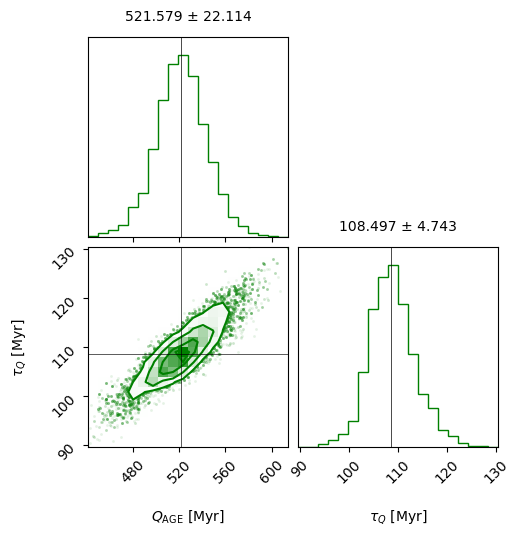

In [32]:
spec = res.spec_crop           # Problem here!
phot = res.phot
polydeg = res.polydeg
spectral_range = (4800, 7000)   #res.spectral_range THIS DOES NOT WORK!!! PROBLEM HERE!
treat_upp_lim = res.treat_as_upper_limits

# Load fitter
from pathlib import Path
filename = Path(res.model_file).name

fitter = PFitter(model_file='new_models/'+filename,
             model_pars=['TRUNCAGE','TRUNCTAU',], 
             uv_bump = False,
             leitatt = False,
            )


res.cornerplot(parameters=['TRUNCAGE','TRUNCTAU'],
               #cmap='Greens',
               show_stats=True, 
               show_histograms=True,          
               #contour_color='k',
               mark_point="median",
               mark_color='black',
               contour_color='green',
               mark_lw=0.5
              )


In [33]:
res.best_model(method='median',quantiles=[0.1,0.9])

{'TRUNCAGE': (494.26960537120453, 521.5395420108453, 549.5362651224755),
 'TRUNCTAU': (103.24076681569035, 108.49604047709892, 115.09396840015972),
 'fesc': (-0.07247457147372122, -0.00901119718774725, 0.08587861669079429),
 'ion_gas': (-1.346430724355307, -1.1231335493005226, -1.0195640220220599),
 'age_gas': (5.0141173973208755, 5.189260005536768, 5.580683369526163),
 'av': (0.26557909992751283, 0.2851806319540255, 0.3050797342507839),
 'av_ext': (0.30798625649594763, 0.334298609257424, 0.361433811308339),
 'alpha': (3.2792783404547325, 3.733692954283644, 3.95070100507244),
 'm_star': (9.797638765427477, 9.799252949046561, 9.799880459868776),
 'vel_sys': (9.455708696137567, 10.36770752221084, 12.142165078739632),
 'sigma_vel': (149.32074848312055, 150.88508752783025, 153.28483903606065),
 'sigma_gas': (484.4889422962356, 495.080513550263, 499.2282525086845),
 'spec_noise_scale': (1.9972530928120211,
  1.9991497561001212,
  1.9998765898049253),
 'redshift': (0.01872, 0.01872, 0.01872)

In [36]:
params = res.best_model()
print(params)

{'TRUNCAGE': 520.1159553776125, 'TRUNCTAU': 108.74001696160596, 'fesc': -0.009993024111843246, 'ion_gas': -1.0020550519324494, 'age_gas': 5.048008762477047, 'av': 0.28707849808820196, 'av_ext': 0.3484640745675224, 'alpha': 3.8472317373684772, 'm_star': 9.799636228519221, 'vel_sys': 9.898235651199741, 'sigma_vel': 149.97222317170818, 'sigma_gas': 499.31808203417404, 'spec_noise_scale': 1.9997370267000316, 'redshift': 0.01872, 'luminosity_distance': 95.2}


In [35]:
# OTHER PARAMETERS
"""
params = {'TRUNCAGE': 139.87001384154837, 
 'TRUNCTAU': 29.61790099279115, 
 'fesc': -0.000243747170200221, 
 'ion_gas': -3.9995062065345475, 
 'age_gas': 0.5304631846589246, 
 'av': 0.030588025595729887, 
 'av_ext': 0.03811362250582504, 
 'alpha': 3.9281772048000856, 
 'm_star': 8.91760084644403, 
 'vel_sys': 157.6048141898533, 
 'sigma_vel': 48.632520662284676, 
 'sigma_gas': 411.43286276323767, 
 'spec_noise_scale': 0.8820851469834907, 
 'redshift': 0.023974, 
 'luminosity_distance': 104}
"""

HEI


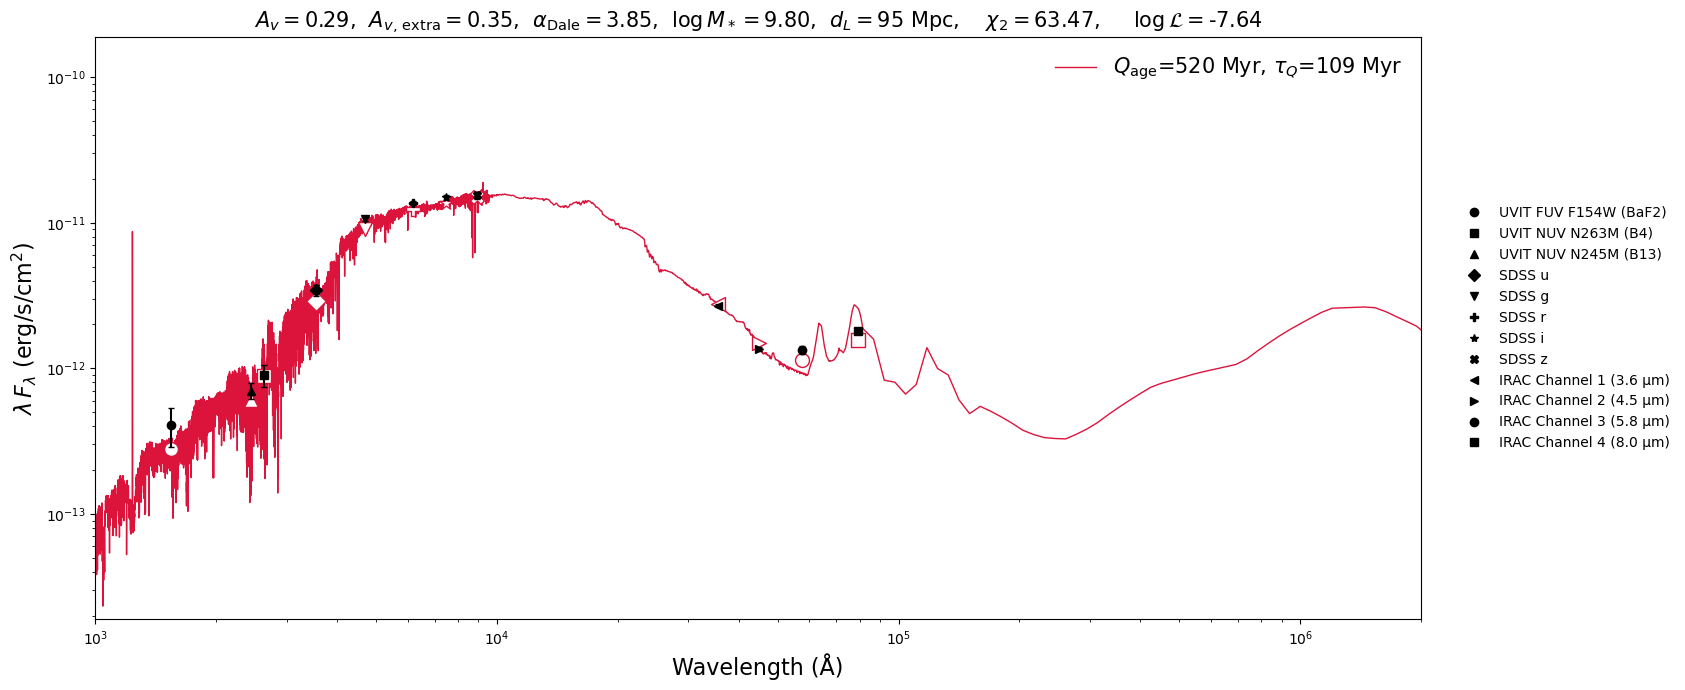

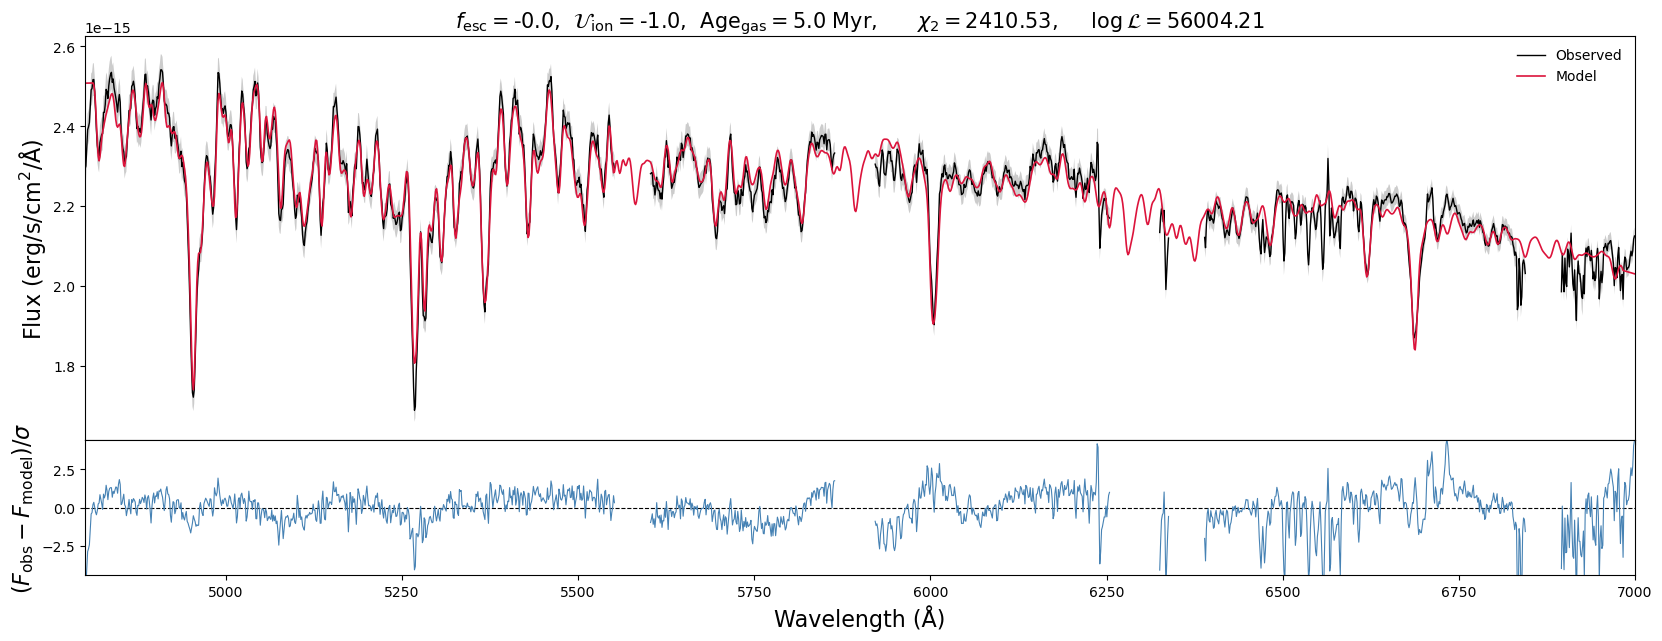

In [37]:


spec_legend_pars = {
    'TRUNCAGE': dict(label="$Q_\\text{age}$", unit="Myr", fmt=".0f"),
    'TRUNCTAU': dict(label="$\\tau_Q$", unit="Myr", fmt=".0f"),
    #'av':    dict(label="$A_V$", unit="", fmt=".2f"),
}

fitter.fit_diagnostic(
        params=params,
        spec=spec,
        spectral_range=spectral_range,
        polydeg=polydeg,
        phot=phot,
    
        color='crimson',
        treat_as_upper_limits=treat_upp_lim,  #['galex_nuv','herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um'],
        winf_spec=4800,wsup_spec=7000,
        winf_phot=1e3,wsup_phot=2e6,
        spec_legend_pars=spec_legend_pars,
        spec_legend_fontsize=15,
        title_fontsize=15,
        title_color='black',
        label_fontsize=16,
    )

# Multicornerplot

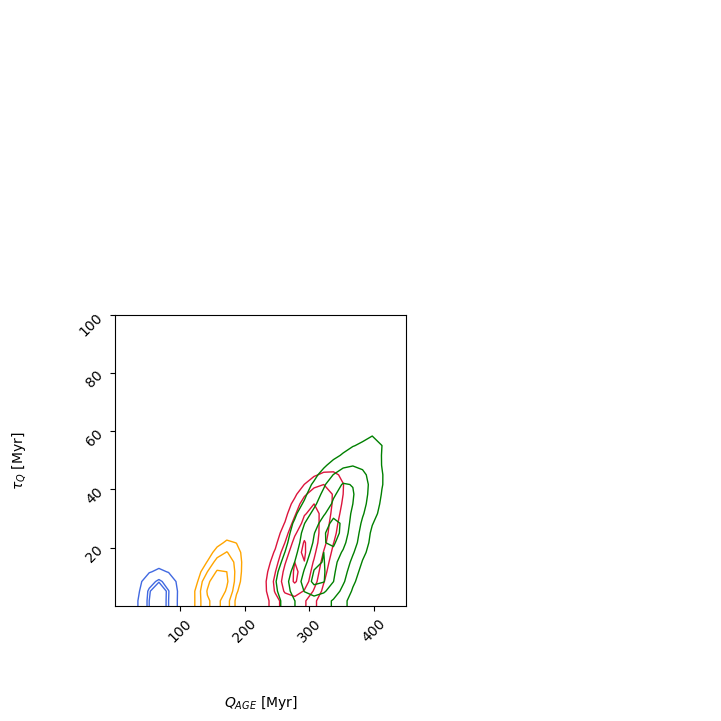

In [21]:
fig = multi_corner_contours(
    fitters=[gmp3779_1_allfree,gmp3779_2_allfree,gmp3779_3_allfree,gmp3779_4_allfree],
    #fitters=[gmp3779_1_noemm,gmp3779_2_noemm,gmp3779_3_noemm,gmp3779_4_noemm],
    parameters=["TRUNCAGE", "TRUNCTAU"], 
    ranges = [(0,450),(0,100)], 
    labels=[r"$Q_{AGE}$ [Myr]", r"$\tau_Q$ [Myr]"],
    #legend_labels=["only phot", "only phot, no PACS", "phot+spec", "phot+spec, $f_\\text{esc}=0$"],
    colors=["royalblue", "orange", "crimson", "green"],
    linewidths=1,
    #show_histograms=True,
)

plt.show()

# Sommary Plot for Coma

In [22]:
galaxies = {

    "ngc4848": (
        [ngc4848_1_allfree, ngc4848_2_allfree, ngc4848_3_allfree],
        [7, 9, 12.5]
    ),

    "ic4040": (
        [ic4040_1_allfree, ic4040_2_allfree, ic4040_3_allfree],
        [5, 7, 9]
    ),

    "gmp3779": (
        [gmp3779_1_allfree, gmp3779_2_allfree, gmp3779_3_allfree, gmp3779_4_allfree],
        [4.5, 6.5, 8.5, 10.5]
    ),

    "d100": (
        [d100_1_allfree, d100_2_allfree],
        [2.75, 4.25]
    ),

    "rb199": (
        [rb199_1_allfree, rb199_2_allfree, rb199_3_allfree],
        [1,3,5]
    ),

    "gmp3016": (
        [gmp3016_1_allfree, gmp3016_2_allfree, gmp3016_3_allfree],
        [1,2.75,4.25]
    ),

    "gmp4232": (
        [gmp4232_1_allfree, gmp4232_2_allfree, gmp4232_3_allfree],
        [1,2.75,4.25]
    ),
}



In [23]:
def extract_trunc_params(models, quantiles=(0.16, 0.84)):
    ages, ages_lo, ages_hi = [], [], []
    taus, taus_lo, taus_hi = [], [], []

    for m in models:
        p = m.best_model(method="median", quantiles=quantiles)

        ages.append(p["TRUNCAGE"][1])
        ages_lo.append(p["TRUNCAGE"][1]-p["TRUNCAGE"][0])
        ages_hi.append(p["TRUNCAGE"][2]-p["TRUNCAGE"][1])

        taus.append(p["TRUNCTAU"][1])
        taus_lo.append(p["TRUNCTAU"][1]-p["TRUNCTAU"][0])
        taus_hi.append(p["TRUNCTAU"][1]-p["TRUNCTAU"][0])

    return (
        ages, ages_lo, ages_hi,
        taus, taus_lo, taus_hi
    )

results = {}

for name, (models, radii) in galaxies.items():

    ages, ages_lo, ages_hi, taus, taus_lo, taus_hi = extract_trunc_params(models)

    results[name] = {
        "r": radii,
        "age": ages,
        "age_lo": ages_lo,
        "age_hi": ages_hi,
        "tau": taus,
        "tau_lo": taus_lo,
        "tau_hi": taus_hi
    }


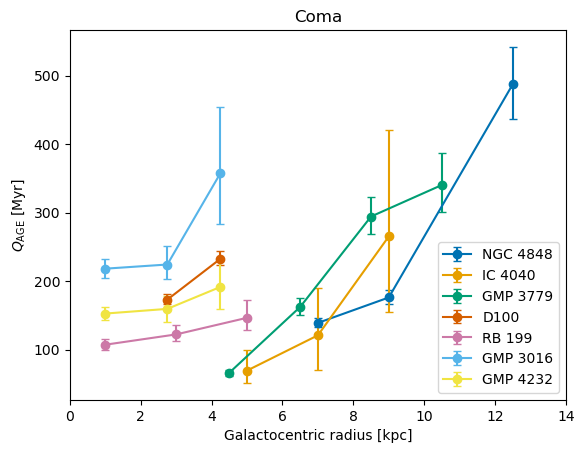

In [24]:


colors = {
    "ngc4848": "#0072B2",   # blue
    "ic4040": "#E69F00",    # orange
    "gmp3779": "#009E73",   # bluish green
    "d100": "#D55E00",      # vermillion
    "rb199": "#CC79A7",     # purple/pink
    "gmp3016": "#56B4E9",   # light blue
    "gmp4232": "#F0E442"    # yellow
}
names = {
    "ngc4848": "NGC 4848",   # blue
    "ic4040": "IC 4040",    # orange
    "gmp3779": "GMP 3779",   # bluish green
    "d100": "D100",      # vermillion
    "rb199": "RB 199",     # purple/pink
    "gmp3016": "GMP 3016",   # light blue
    "gmp4232": "GMP 4232"    # yellow
}



plt.figure()

for name, data in results.items():

    if len(data["r"]) == 0:
        continue

    plt.errorbar(
        data["r"],
        data["age"],
        yerr=[data["age_lo"], data["age_hi"]],
        fmt='o-',                     # marker + connecting line
        color=colors[name],           # your chosen color
        capsize=3,                    # nice small caps on errorbars
        label=names[name]
    )

plt.xlim(0,14)
plt.xlabel("Galactocentric radius [kpc]")
plt.ylabel("$Q_\\text{AGE}$ [Myr]")
plt.title("Coma")
plt.legend(loc='lower right')
plt.show()

# Summary plot for A1367

In [26]:
galaxies = {

    "ugc6697": (
        [ugc6697_1_allfree,ugc6679_2_allfree],
        [15,20]
    ),

    "2masx": (
        [twomasx_1_allfree, twomasx_2_allfree],
        [4,7]
    ),

    "ngc3860": (
        [ngc3860_1_allfree,ngc3860_2_allfree,ngc3860_3_allfree],
        [7.5,10.5,13.5]
    ),

}


In [27]:
results = {}

for name, (models, radii) in galaxies.items():

    ages, ages_lo, ages_hi, taus, taus_lo, taus_hi = extract_trunc_params(models)

    results[name] = {
        "r": radii,
        "age": ages,
        "age_lo": ages_lo,
        "age_hi": ages_hi,
        "tau": taus,
        "tau_lo": taus_lo,
        "tau_hi": taus_hi
    }


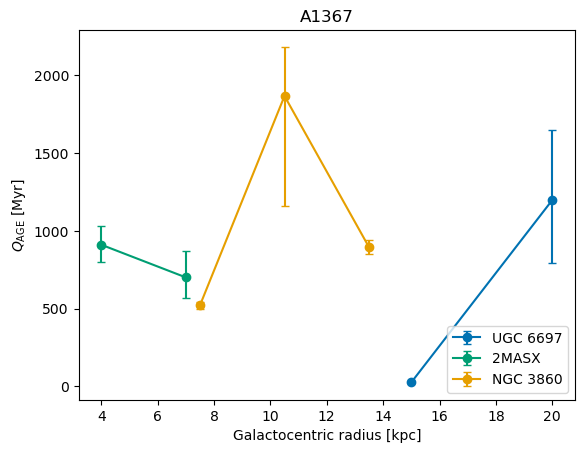

In [30]:
colors = {
    "ugc6697": "#0072B2",   # blue
    "ngc3860": "#E69F00",    # orange
    "2masx": "#009E73",   # bluish green
}
names = {
    "ugc6697": "UGC 6697",   # blue
    "ngc3860": "NGC 3860",    # orange
    "2masx": "2MASX",   # bluish green
}



plt.figure()

for name, data in results.items():

    if len(data["r"]) == 0:
        continue

    plt.errorbar(
        data["r"],
        data["age"],
        yerr=[data["age_lo"], data["age_hi"]],
        fmt='o-',                     # marker + connecting line
        color=colors[name],           # your chosen color
        capsize=3,                    # nice small caps on errorbars
        label=names[name]
    )

#plt.xlim(0,14)
plt.xlabel("Galactocentric radius [kpc]")
plt.ylabel("$Q_\\text{AGE}$ [Myr]")
plt.title("A1367")
plt.legend(loc='lower right')
plt.show()
